<a href="https://colab.research.google.com/github/aesquivel94/operational-error-analyzer/blob/main/warehouse_operational_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Operational Error Analyzer**

Warehouse errors are rarely isolated events. A scan failure, labeling issue, or wrong item can ripple through the workflow, creating delays, rework, and hidden operational costs. Over time, these issues impact customer satisfaction by increasing wait times, reducing service quality, and leading to incorrect orders.

This project analyzes warehouse operational errors to identify where failures concentrate, which issues generate the highest operational cost, and how errors propagate across process steps.

Rather than treating errors as independent events, this analysis focuses on understanding systemic patterns that drive inefficiency. The goal is to uncover high-impact failure points and translate them into actionable insights that support better operational decision-making.

## Executive Summary

This project analyzes warehouse operational errors to identify where failures concentrate, which issues generate the highest operational cost, and how errors propagate across the workflow.

### Key Findings

• Scan failures act as upstream trigger events, increasing the likelihood of downstream errors.  
• Certain workflow steps concentrate a disproportionate number of issues, indicating operational risk hotspots.  
• Error chains reveal that failures are systemic and interconnected, rather than isolated events.  

### Business Impact

These findings show that warehouse errors should not be prioritized by frequency alone, but by their combined impact on operational cost and downstream risk. Targeting high-impact and high-propagation errors can reduce total time loss, improve process reliability, and prevent cascading failures across the workflow.

## Business Problem

Warehouse operations depend on speed, accuracy, and process consistency. When errors occur, they create hidden costs through rework, delays, and workflow disruptions that impact both efficiency and customer satisfaction.

A key challenge is that errors are often treated as isolated events, making it difficult to identify where failures concentrate, which issues generate the greatest operational cost, and how problems propagate across the workflow.

Without this visibility, improvement efforts may focus on the most visible errors rather than the ones that drive the highest overall impact.

This project addresses that gap by analyzing warehouse errors to uncover high-impact failure points and support more effective, data-driven operational decisions.

## Project Objectives

This project moves beyond basic error tracking to understand how operational failures impact performance across the workflow.

The analysis focuses on:

• Identify the most frequent operational errors  
• Measure which errors generate the highest operational time loss  
• Detect where errors concentrate across workflow stages  
• Analyze recurring error chains and their dependencies  
• Evaluate whether errors can be predicted using operational context  
• Recommend targeted actions to improve operational efficiency

## Dataset and Simulation Design

This project uses a synthetic dataset designed to reflect realistic warehouse operations. The data simulates common workflow stages, error types, and their impact on operational performance.

### Key Features of the Simulation
• Process-specific error probabilities to reflect differences across workflow stages  
• Root-cause relationships between errors to simulate downstream effects  
• Identifier types such as SKU, barcode, and LPN  
• Estimated time impact associated with each error type  
• Simulated error chains to model how failures propagate through the system  

### Assumptions

This dataset is not based on real production data but is designed to approximate realistic operational behavior.

While the simulation captures key patterns such as error distribution, impact, and propagation, it simplifies real-world complexity. In production environments, additional factors such as workload, staffing, and time pressure would influence error behavior.

The goal of this dataset is to demonstrate how data analysis can be used to identify patterns, quantify operational impact, and support decision-making.

In [19]:
## Import Packages and Setup

# Purpose:
# Load required libraries for data analysis, visualization, and modeling,
# and define a consistent visual style for all charts.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as mtick
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Set consistent visualization style
sns.set_theme(style="whitegrid")

In [20]:
# Purpose:
# Simulate warehouse error events with process-specific patterns,
# root causes, identifier types, and estimated operational impact.

# Reproducible random seed
rng = np.random.default_rng(42)

# Number of simulated events
n = 400

# Operational dimensions
shifts = ["A", "B", "C"]
process_steps = ["receiving", "picking", "packing", "back_to_stock"]

# Error probabilities by process step
step_error_weights = {
    "receiving": {
        "scan_failure": 0.35,
        "damage": 0.30,
        "lpn_error": 0.25,
        "missing_item": 0.10,
    },
    "picking": {
        "wrong_item": 0.35,
        "missing_item": 0.30,
        "lpn_error": 0.20,
        "scan_failure": 0.15,
    },
    "packing": {
        "wrong_item": 0.30,
        "damage": 0.25,
        "scan_failure": 0.25,
        "missing_item": 0.20,
    },
    "back_to_stock": {
        "missing_item": 0.35,
        "lpn_error": 0.30,
        "scan_failure": 0.20,
        "wrong_item": 0.15,
    },
}

# Root-cause mappings by error type
error_to_root = {
    "wrong_item": ["incorrect_location", "training_gap", "mislabel"],
    "missing_item": ["inventory_mismatch", "incorrect_location", "system_lag"],
    "scan_failure": ["damaged_label", "system_lag", "mislabel"],
    "lpn_error": ["mislabel", "system_lag", "training_gap"],
    "damage": ["training_gap", "incorrect_location", "damaged_label"],
}

# Identifier types associated with each error
error_to_identifier = {
    "wrong_item": ["sku", "barcode"],
    "missing_item": ["sku", "lpn"],
    "scan_failure": ["barcode", "lpn"],
    "lpn_error": ["lpn"],
    "damage": ["barcode", "sku"],
}

def weighted_choice(options_dict):
    """Sample a value using predefined probabilities."""
    options = list(options_dict.keys())
    probs = list(options_dict.values())
    return rng.choice(options, p=probs)

# Simulated event dates
start = np.datetime64("2025-01-01")
dates = start + rng.integers(0, 90, size=n).astype("timedelta64[D]")

rows = []

# Simulate warehouse error events
for i in range(n):

    # Operational context
    shift = rng.choice(shifts, p=[0.36, 0.34, 0.30])
    step = rng.choice(process_steps, p=[0.20, 0.35, 0.25, 0.20])

    # Error attributes
    error_type = weighted_choice(step_error_weights[step])
    root_cause = rng.choice(error_to_root[error_type])
    identifier_type = rng.choice(error_to_identifier[error_type])

    # Estimated time impact
    base = rng.gamma(shape=2.0, scale=7.0)

    multiplier = {
        "missing_item": 1.4,
        "wrong_item": 1.3,
        "lpn_error": 1.2,
        "scan_failure": 1.0,
        "damage": 1.1,
    }[error_type]

    impact_minutes = int(round(base * multiplier))

    rows.append([
        str(dates[i]),
        shift,
        step,
        error_type,
        root_cause,
        identifier_type,
        impact_minutes
    ])

# Final simulated dataset
df = pd.DataFrame(rows, columns=[
    "date",
    "shift",
    "process_step",
    "error_type",
    "root_cause",
    "identifier_type",
    "impact_minutes"
])

df.head()

,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19


In [21]:
# Purpose:
# Validate dataset structure, data types, and completeness
# to ensure it is suitable for analysis.

print("🔹 Preview of dataset")
display(df.head())

print("\n🔹 Dataset structure")
df.info()

print("\n🔹 Summary statistics")
display(df.describe())

print("\n🔹 Missing values")
display(df.isnull().sum())

print("\n🔹 Frequency by error type")
display(df["error_type"].value_counts())

🔹 Preview of dataset


,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19



🔹 Dataset structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             400 non-null    object
 1   shift            400 non-null    object
 2   process_step     400 non-null    object
 3   error_type       400 non-null    object
 4   root_cause       400 non-null    object
 5   identifier_type  400 non-null    object
 6   impact_minutes   400 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 22.0+ KB

🔹 Summary statistics


,impact_minutes
count,400.000000
mean,17.162500
std,12.176278
min,1.000000
25%,8.750000
50%,15.000000
75%,23.000000
max,75.000000



🔹 Missing values


,0
date,0
shift,0
process_step,0
error_type,0
root_cause,0
identifier_type,0
impact_minutes,0



🔹 Frequency by error type


,count
error_type,
missing_item,96
wrong_item,94
scan_failure,91
lpn_error,70
damage,49


### Validation Notes

The dataset is well-structured and suitable for analysis:

• All core operational variables are complete, with no missing values  
• Error types are reasonably balanced across categories, supporting meaningful comparisons  

This validation step ensures that the dataset is consistent and reliable for further analysis and modeling.

## Error Frequency Analysis

Question  
Which operational errors occur most frequently?

This analysis identifies the most common error types, providing an initial view of where operational issues are concentrated.

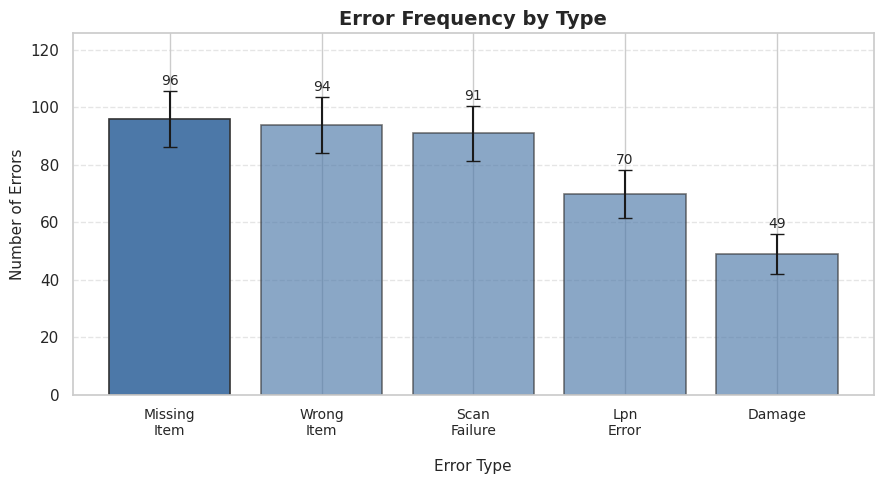

In [22]:
# Purpose:
# Identify the most frequent error types to establish
# a baseline view of operational issue distribution.

error_counts = df["error_type"].value_counts()

# Format category labels for readability
def format_label(text):
    words = text.replace("_", " ").title().split()

    if len(words) == 2:
        return f"{words[0]}\n{words[1]}"

    return "\n".join(words)

labels = [format_label(x) for x in error_counts.index]

# Approximate variability for visual context
error = np.sqrt(error_counts.values)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    labels,
    error_counts.values,
    yerr=error,
    capsize=5,
    color="#4C78A8",
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Add value labels above bars
for i, v in enumerate(error_counts.values):
    plt.text(
        i,
        v + error[i] + 2,
        str(v),
        ha="center",
        fontsize=10
    )

# Highlight the most frequent error
max_idx = error_counts.values.argmax()

for i, bar in enumerate(bars):
    bar.set_alpha(1.0 if i == max_idx else 0.65)

# Format y-axis labels
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.title("Error Frequency by Type", fontsize=14, weight="bold")
plt.ylabel("Number of Errors", fontsize=11)
plt.xlabel("Error Type", fontsize=11, labelpad=15)
plt.xticks(fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.ylim(0, max(error_counts.values + error) + 20)
plt.tight_layout()
plt.show()

### Key Insight

The top three errors — Missing Item, Wrong Item, and Scan Failure — occur at similar frequencies, indicating that no single error type dominates the process.

This suggests that operational inefficiencies are distributed across multiple failure points rather than concentrated in a single area, making targeted prioritization more important than focusing on frequency alone.

In [23]:
# Purpose:
# Summarize key operational metrics to highlight
# the most frequent and highest-impact error types.

total_errors = len(df)
total_minutes = df["impact_minutes"].sum()

# Most frequent error type
top_error = (
    df["error_type"]
    .value_counts()
    .idxmax()
    .replace("_", " ")
    .title()
)

# Error type with highest total time impact
top_impact = (
    df.groupby("error_type")["impact_minutes"]
    .sum()
    .idxmax()
    .replace("_", " ")
    .title()
)

print("🔹 Operational Summary\n")
print(f"📊 Total Errors: {total_errors}")
print(f"⏱️ Total Minutes Lost: {total_minutes:,}")
print(f"🔁 Most Frequent Error: {top_error}")
print(f"💥 Highest-Impact Error: {top_impact}")

🔹 Operational Summary

📊 Total Errors: 400
⏱️ Total Minutes Lost: 6,865
🔁 Most Frequent Error: Missing Item
💥 Highest-Impact Error: Missing Item


Key Insight

Missing Item is both the most frequent and the highest-impact error, making it the most critical area for operational improvement.

This alignment between frequency and impact indicates a high-leverage intervention point, where targeted improvements can reduce both error volume and total operational time loss.

## Errors by Process Step

**Question**

Where do operational errors occur within the workflow?

This analysis examines how error types are distributed across process steps to identify where failures concentrate and where intervention is most needed.

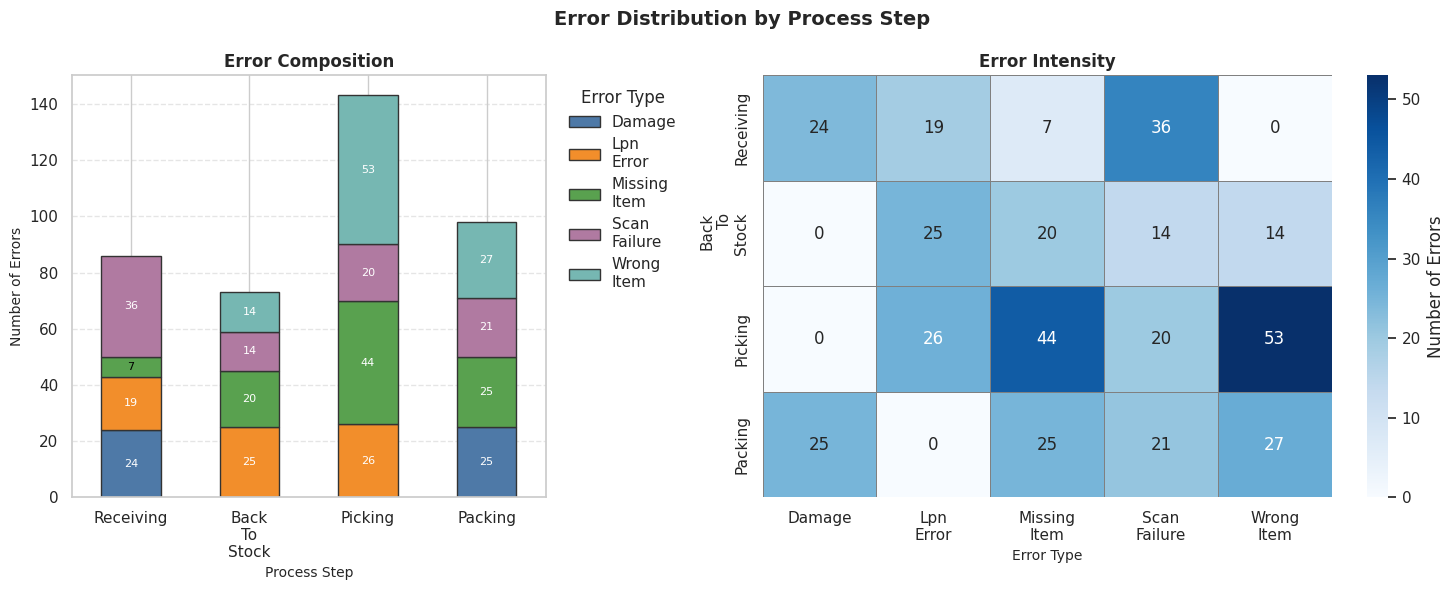

In [24]:
# Purpose:
# Analyze how errors are distributed across workflow steps
# to identify operational risk hotspots and concentration points.

# -----------------------------
# Error distribution by process step (split layout)
# -----------------------------
step_errors = pd.crosstab(df["process_step"], df["error_type"])

process_order = ["receiving", "back_to_stock", "picking", "packing"]
step_errors = step_errors.loc[process_order]

# Format labels
def format_label(text):
    words = text.replace("_", " ").title().split()
    return "\n".join(words)

step_errors.index = [format_label(x) for x in step_errors.index]
step_errors.columns = [format_label(x) for x in step_errors.columns]

# Colorblind-friendly palette
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#B07AA1", "#76B7B2"]

# Create split layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.5]})

# -----------------------------
# Left: Stacked Bar Chart
# -----------------------------
ax = axes[0]

step_errors.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="#333333",
    linewidth=1
)

ax.set_title("Error Composition", fontsize=12, weight="bold")
ax.set_xlabel("Process Step", fontsize=10)
ax.set_ylabel("Number of Errors", fontsize=10)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Move legend OUTSIDE
ax.legend(
    title="Error Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# -----------------------------
# Add labels inside stacked bars
# -----------------------------
for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        if height > 0:  # avoid labeling empty segments
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                int(height),
                ha="center",
                va="center",
                fontsize=8,
                color="white" if height > 10 else "black"
            )

# -----------------------------
# Right: Heatmap
# -----------------------------
sns.heatmap(
    step_errors,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Number of Errors"},
    ax=axes[1]
)

axes[1].set_title("Error Intensity", fontsize=12, weight="bold")
axes[1].set_xlabel("Error Type", fontsize=10)
axes[1].set_ylabel("")

# Global title
plt.suptitle("Error Distribution by Process Step", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

#### Key Insight

Errors are not evenly distributed across the workflow. The picking stage stands out as the primary operational risk hotspot, with a high concentration of wrong_item and missing_item errors.

In contrast, earlier stages such as receiving show a different error profile, with more scan_failure and damage issues, indicating that each process step faces distinct operational challenges.

#### Focus Area

The picking process represents the highest-priority intervention point, as it concentrates the most critical errors affecting order accuracy.

Because picking directly determines what reaches the customer, failures at this stage are more likely to propagate downstream, increasing rework, delays, and customer impact.

## Operational Time Lost by Error Type

**Question**  
* Which operational errors generate the greatest time loss?

* Not all errors are equal. Some occur frequently, while others consume significantly more time and resources.

* This analysis measures the total time lost per error type to identify which failures drive the highest operational cost.

* In operational environments, the most frequent issue is not always the most expensive one.

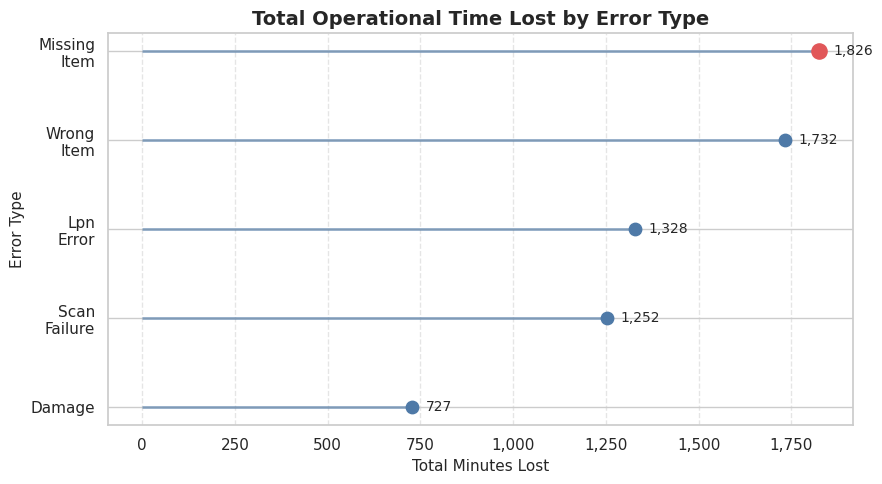

In [25]:
# Purpose:
# Quantify total operational time loss by error type
# to identify the highest-cost failure points.

# -----------------------------
# Total operational time lost by error type
# -----------------------------
cost_analysis = (
    df.groupby("error_type")["impact_minutes"]
    .sum()
    .sort_values(ascending=True)
)

# Format category labels for readability
def format_label(text):
    return "\n".join(text.replace("_", " ").title().split())

labels = [format_label(x) for x in cost_analysis.index]
values = cost_analysis.values

plt.figure(figsize=(9, 5))

# Draw reference lines for comparison
plt.hlines(
    y=labels,
    xmin=0,
    xmax=values,
    color="#4E79A7",
    alpha=0.6,
    linewidth=2
)

# Plot points for each error type
plt.scatter(
    values,
    labels,
    color="#4E79A7",
    s=80
)

# Emphasize the highest-impact error
max_idx = values.argmax()
plt.scatter(
    values[max_idx],
    labels[max_idx],
    color="#E15759",
    s=120,
    zorder=3
)

# Display values for quick comparison
offset = max(values) * 0.02
for i, v in enumerate(values):
    plt.text(
        v + offset,
        labels[i],
        f"{v:,}",
        va="center",
        fontsize=10
    )

plt.title("Total Operational Time Lost by Error Type", fontsize=14, weight="bold")
plt.xlabel("Total Minutes Lost", fontsize=11)
plt.ylabel("Error Type", fontsize=11)

# Improve readability with vertical reference lines
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Format x-axis labels with commas
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

**Key Insight**

Operational time loss is highly concentrated, with a small number of error types driving a disproportionate share of total impact.

Missing Item is the dominant cost driver, combining high frequency with significant recovery time. This makes it the highest-priority target for process improvement.

**Focus Area**

Prioritize improvements in processes related to Missing Item errors, particularly in areas involving inventory accuracy and item tracking.

Reducing this error type represents the highest-leverage opportunity to decrease total operational time loss and improve overall process efficiency.


## Simulating Error Propagation

What goes here:

previous_error logic
explanation that chains are simulated to model downstream failure patterns

Why this matters:
Separate this from the analysis.
Right now it is mixed into the middle.
It should become its own clear setup step.


In [26]:
# Purpose:
# Create a simplified sequential error variable to analyze
# how one error may be followed by another.

df["previous_error"] = df["error_type"].shift(1)
df["previous_error"] = df["previous_error"].fillna("no_previous")

## Recurring Error Chain Analysis

**Question**

Which operational errors tend to trigger downstream issues?

Operational failures rarely occur in isolation. One process breakdown can propagate downstream and generate additional errors.

This analysis identifies the most frequent error-to-error transitions, helping reveal systemic weaknesses in the workflow.

Understanding these patterns allows operations teams to target root causes instead of isolated symptoms.

In [27]:
# Purpose:
# Identify the most frequent error-to-error transitions
# to highlight recurring downstream failure patterns.

chain_counts = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_chains = chain_counts.head(10).copy()
top_chains

,previous_error,error_type,count
24,wrong_item,scan_failure,28
18,scan_failure,missing_item,25
14,missing_item,wrong_item,24
11,missing_item,lpn_error,24
20,scan_failure,wrong_item,23
12,missing_item,missing_item,22
9,lpn_error,wrong_item,21
19,scan_failure,scan_failure,20
22,wrong_item,lpn_error,19
7,lpn_error,missing_item,18


## Error Transition Matrix

**Question**  
How likely is one error to be followed by another?

Operational errors are not independent events. A failure in one step can increase the probability of subsequent errors.

This analysis converts error-to-error sequences into transition probabilities and visualizes them as a matrix, revealing how failures propagate across the workflow.

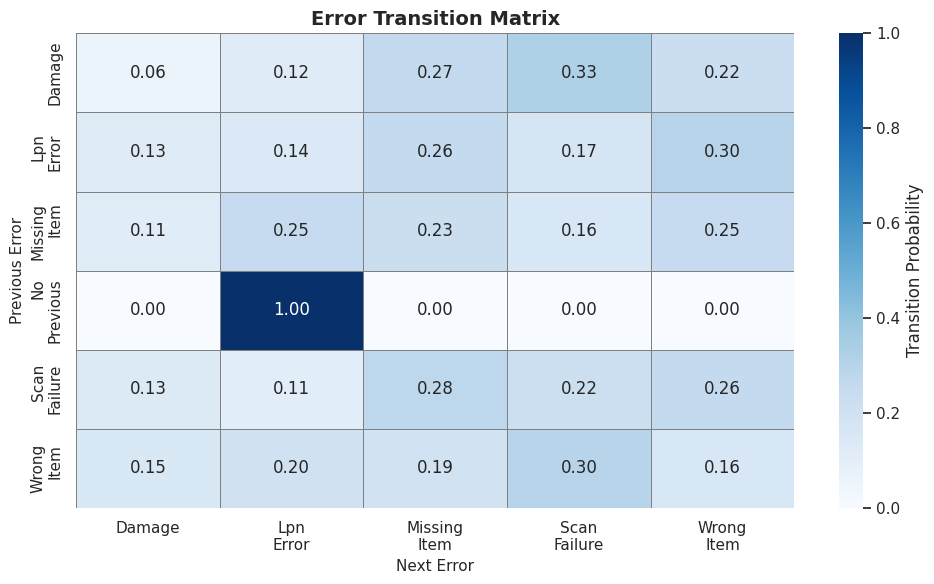

In [28]:
# Purpose:
# Quantify and visualize how errors transition from one type to another
# to identify downstream propagation patterns.

# Create transition counts
transition_counts = pd.crosstab(
    df["previous_error"],
    df["error_type"]
)

# Convert counts to probabilities (row-wise)
transition_probs = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

# Format labels for readability
def format_label(text):
    return "\n".join(text.replace("_", " ").title().split())

transition_probs.index = [format_label(x) for x in transition_probs.index]
transition_probs.columns = [format_label(x) for x in transition_probs.columns]

plt.figure(figsize=(10, 6))

sns.heatmap(
    transition_probs,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Transition Probability"}
)

plt.title("Error Transition Matrix", fontsize=14, weight="bold")
plt.xlabel("Next Error", fontsize=11)
plt.ylabel("Previous Error", fontsize=11)

plt.tight_layout()
plt.show()

In [29]:
# Top transition probabilities
transition_probs.stack().sort_values(ascending=False).head(5)

,,0
No\nPrevious,Lpn\nError,1.000000
Damage,Scan\nFailure,0.326531
Lpn\nError,Wrong\nItem,0.300000
Wrong\nItem,Scan\nFailure,0.297872
Scan\nFailure,Missing\nItem,0.277778


### Key Insight

Error transitions are not random. Certain error types show a higher likelihood of leading to specific downstream failures, indicating structured propagation patterns within the workflow.

In particular, errors related to item identification and scanning are more likely to trigger subsequent issues, reinforcing their role as critical upstream failure points.

This suggests that addressing upstream errors can prevent multiple downstream failures, amplifying the impact of targeted improvements.

To complement the transition matrix, this visualization highlights the most significant error flows, providing a more intuitive view of how failures propagate across the workflow.

In [30]:
# -----------------------------
# Prepare transition data
# -----------------------------
sankey_data = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .reset_index(name="count")
)

# Remove events without a prior error
sankey_data = sankey_data[sankey_data["previous_error"] != "no_previous"].copy()

# Keep only the strongest transitions to reduce clutter
sankey_data = sankey_data.sort_values("count", ascending=False).head(10)

# Format labels for readability
def format_label(text):
    return text.replace("_", " ").title()

# Create separate node groups for source and target
left_nodes = [f"Previous: {format_label(x)}" for x in sankey_data["previous_error"].unique()]
right_nodes = [f"Next: {format_label(x)}" for x in sankey_data["error_type"].unique()]
all_nodes = left_nodes + right_nodes

# Map node labels to indices
node_index = {label: i for i, label in enumerate(all_nodes)}

# Build source and target indices
sources = sankey_data["previous_error"].map(
    lambda x: node_index[f"Previous: {format_label(x)}"]
)
targets = sankey_data["error_type"].map(
    lambda x: node_index[f"Next: {format_label(x)}"]
)
values = sankey_data["count"]

# Color mapping for error types
color_map = {
    "Damage": "#4E79A7",
    "Lpn Error": "#F28E2B",
    "Missing Item": "#59A14F",
    "Scan Failure": "#B07AA1",
    "Wrong Item": "#E15759",
}

# Assign node colors
node_colors = []
for node in all_nodes:
    error_name = node.split(": ", 1)[1]
    node_colors.append(color_map.get(error_name, "#76B7B2"))

# Convert hex colors to RGBA for softer links
def hex_to_rgba(hex_color, alpha=0.35):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

# Color links based on their source error
link_colors = [
    hex_to_rgba(color_map.get(format_label(prev), "#76B7B2"), alpha=0.35)
    for prev in sankey_data["previous_error"]
]

# Position nodes explicitly for a clearer left-to-right layout
left_x = [0.08] * len(left_nodes)
right_x = [0.88] * len(right_nodes)

left_y = list(pd.Series(range(len(left_nodes))).rank(pct=True))
right_y = list(pd.Series(range(len(right_nodes))).rank(pct=True))

# -----------------------------
# Build Sankey diagram
# -----------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=25,
                thickness=22,
                line=dict(color="rgba(50,50,50,0.5)", width=0.8),
                label=all_nodes,
                color=node_colors,
                x=left_x + right_x,
                y=left_y + right_y
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors
            )
        )
    ]
)

fig.update_layout(
    title_text="Error Propagation Flow",
    font=dict(size=12),
    width=1100,
    height=650,
    margin=dict(l=20, r=20, t=50, b=20)
)

fig.show()

### Key Insight

Error propagation is concentrated in a small number of dominant transitions, forming clear downstream failure pathways.

Breaking these high-frequency transitions can prevent multiple downstream errors, making them key targets for operational improvement.

## Error Chain Comparison: Frequency vs Impact

To better understand how failures propagate through the workflow, this analysis compares error chains from two perspectives:

• Frequency: how often each transition occurs  
• Impact: how much operational cost each transition generates  

While previous sections identified common patterns, this comparison highlights a critical distinction: the most frequent failures are not always the most costly.

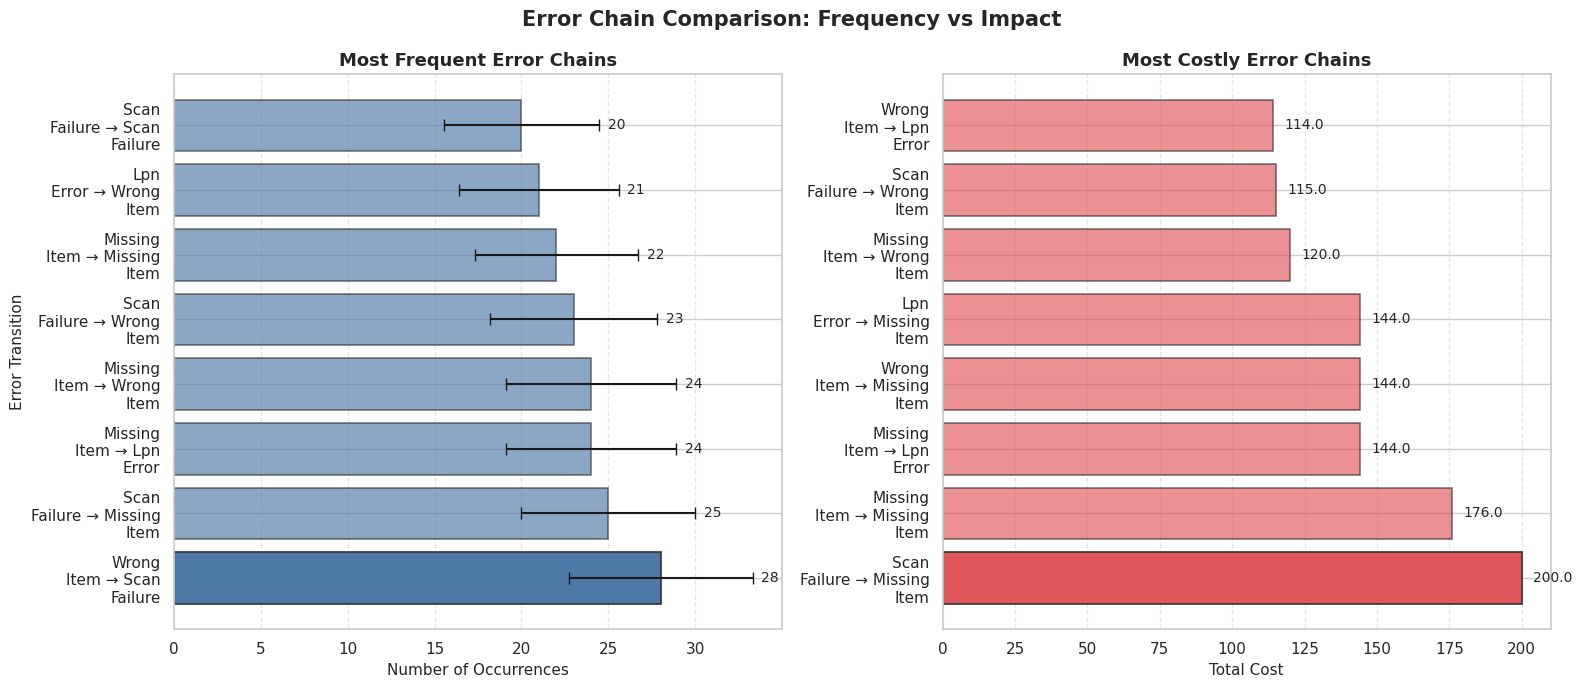

In [31]:
# -----------------------------
# Prepare data
# -----------------------------

# Frequency (Top chains)
freq_data = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .reset_index(name="count")
)

freq_data = freq_data[freq_data["previous_error"] != "no_previous"]
freq_data = freq_data.sort_values("count", ascending=False).head(8)

# Cost (Impact chains)
error_impact = {
    "wrong_item": 5,
    "missing_item": 8,
    "lpn_error": 6,
    "scan_failure": 4
}

df["error_cost"] = df["error_type"].map(error_impact)

cost_data = (
    df.groupby(["previous_error", "error_type"])["error_cost"]
    .sum()
    .reset_index()
    .sort_values(by="error_cost", ascending=False)
    .head(8)
)

# -----------------------------
# Label formatting
# -----------------------------
def format_label(prev, curr):
    return (
        "\n".join(prev.replace("_", " ").title().split())
        + " → " +
        "\n".join(curr.replace("_", " ").title().split())
    )

freq_data["chain"] = [
    format_label(p, c) for p, c in zip(freq_data["previous_error"], freq_data["error_type"])
]

cost_data["chain"] = [
    format_label(p, c) for p, c in zip(cost_data["previous_error"], cost_data["error_type"])
]

# -----------------------------
# Create split layout
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# -----------------------------
# LEFT: Frequency
# -----------------------------
values_f = freq_data["count"].values
labels_f = freq_data["chain"].values
error_f = np.sqrt(values_f)

bars_f = axes[0].barh(
    labels_f,
    values_f,
    xerr=error_f,
    capsize=4,
    color="#4E79A7",
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Highlight max
max_idx_f = values_f.argmax()
for i, bar in enumerate(bars_f):
    bar.set_alpha(1.0 if i == max_idx_f else 0.65)

# Labels
for i, v in enumerate(values_f):
    axes[0].text(v + error_f[i] + 0.5, i, f"{v}", va="center", fontsize=10)

axes[0].set_title("Most Frequent Error Chains", fontsize=13, weight="bold")
axes[0].set_xlabel("Number of Occurrences", fontsize=11)
axes[0].set_ylabel("Error Transition", fontsize=11)
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

# -----------------------------
# RIGHT: Cost
# -----------------------------
values_c = cost_data["error_cost"].values
labels_c = cost_data["chain"].values

bars_c = axes[1].barh(
    labels_c,
    values_c,
    color="#E15759",
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Highlight max
max_idx_c = values_c.argmax()
for i, bar in enumerate(bars_c):
    bar.set_alpha(1.0 if i == max_idx_c else 0.65)

# Labels
for i, v in enumerate(values_c):
    axes[1].text(v + max(values_c) * 0.02, i, f"{v}", va="center", fontsize=10)

axes[1].set_title("Most Costly Error Chains", fontsize=13, weight="bold")
axes[1].set_xlabel("Total Cost", fontsize=11)
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

# -----------------------------
# Global title
# -----------------------------
plt.suptitle("Error Chain Comparison: Frequency vs Impact", fontsize=15, weight="bold")

plt.tight_layout()
plt.show()

### Key Insight

Frequent error chains do not necessarily drive the highest operational cost.

Some transitions occur often but have relatively low impact, while others happen less frequently but consume significantly more time and resources.

## From Analysis to Prediction

**Question**  
Can operational errors be predicted using workflow context?

Building on the patterns identified in previous sections, this step explores whether error occurrence can be partially predicted using available operational signals.

A classification model is trained using key features such as process_step, previous_error, and identifier_type, representing the type of contextual information available in real warehouse environments.

The goal is not to build a production-ready model, but to evaluate whether these patterns can support more proactive decision-making.

In [32]:
# Purpose:
# Create a simple risk feature combining current and prior error impact.

df["risk_score"] = (
    df["error_cost"] +
    df["previous_error"].map(error_impact).fillna(0)
)

In [33]:
# -----------------------------
# Features and target
# -----------------------------
features = ["process_step", "previous_error", "identifier_type"]
X = pd.get_dummies(df[features], drop_first=False)
y = df["error_type"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate
accuracy = model.score(X_test, y_test)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test)))

Accuracy: 0.53

Classification Report:
              precision    recall  f1-score   support

      damage       0.54      0.70      0.61        10
   lpn_error       0.61      0.85      0.71        13
missing_item       0.64      0.28      0.39        25
scan_failure       0.64      0.45      0.53        20
  wrong_item       0.33      0.67      0.44        12

    accuracy                           0.53        80
   macro avg       0.55      0.59      0.54        80
weighted avg       0.58      0.53      0.51        80



### Model Performance

The model achieves an accuracy of 0.53, indicating moderate predictive capability.

Performance varies across error types, with some classes showing stronger recall than others. This suggests that while certain error patterns are predictable, others remain more difficult to capture using limited contextual features.

### Key Insight

Operational errors show partial predictability based on workflow context.

While the model is simplified, it demonstrates that factors such as process step and prior errors influence the likelihood of future failures.

This suggests that predictive approaches could be used to anticipate high-risk scenarios, enabling more proactive operational interventions.

## Operational Recommendations

Based on the analysis of error frequency, process distribution, time impact, and error propagation patterns, the following actions are recommended to improve operational efficiency:

1. Prioritize High-Impact Errors  
Focus on reducing Missing Item errors, as they generate the highest total operational time loss. Improving inventory accuracy and item tracking will deliver the greatest reduction in overall inefficiency.

2. Strengthen the Picking Process  
The picking stage shows the highest concentration of critical errors, particularly wrong_item and missing_item.

Recommended actions:
• Introduce additional verification steps during picking  
• Improve scanning reliability and item identification systems  
• Provide targeted training for picking operations  

3. Address Root Causes to Prevent Error Propagation  
Errors frequently trigger downstream failures. Instead of treating issues in isolation, prioritize eliminating upstream causes.

Reducing initial errors can prevent multiple subsequent failures across the workflow.

4. Implement Risk-Based Monitoring  
Use operational patterns and predictive signals to identify high-risk scenarios.

• Monitor combinations of process steps and prior errors  
• Flag situations with higher likelihood of failure  
• Prioritize intervention where risk is highest  

5. Align Improvements with Impact, Not Just Frequency  
Frequent errors are not always the most costly. Improvement efforts should prioritize:

• Total time loss  
• Propagation potential  
• Cost of recovery  

Focusing on high-impact errors will produce more effective and measurable results.

## Key Takeaways

• Operational inefficiencies are driven by both error frequency and impact  
• Missing Item errors represent the highest-value opportunity for improvement  
• Errors are process-dependent, with picking as a key risk area  
• Failures propagate across the workflow and should be addressed at the source  
• Error patterns show partial predictability, enabling proactive intervention

## Next Steps

• Validate findings using real operational data  
• Enhance propagation analysis with advanced methods (e.g., Markov chains)  
• Incorporate financial cost estimates beyond time loss  
• Test recommended interventions in controlled environments  
• Expand predictive models with additional operational features

> This analysis demonstrates how operational data can be used not only to understand performance issues, but to prioritize high-impact interventions and support more proactive decision-making.

# Operational Considerations

While this analysis focuses on structured operational data, real-world warehouse environments introduce additional sources of error that are not captured in the dataset.

System reliability plays a critical role. Scanner disconnections, system latency, and integration issues between multiple software platforms can lead to data inconsistencies, ghost inventory, and locked orders.

Human factors also influence error rates. Processes that rely heavily on manual work are more susceptible to variability, especially in environments with high workforce turnover or limited training. In contrast, highly automated systems shift risk toward technology reliability and maintenance.

These factors highlight that operational errors are influenced by both process design and system infrastructure. Future analyses could incorporate these dimensions to better reflect real-world complexity and improve the robustness of recommendations.